## Section 1  Study question and setup

Item,Value
Rows in dataset,943
Failure rate,0.417
Target column,fail
Train split approach,train / validation / test
Check cost per machine,10.0
Base missed failure loss,500.0
Recovery rate,1.0
Severity shrink alpha,0.50
Surge extra cost per check,5.0
Surge fixed activation cost,100.0


Label,Rule
small,5 to 30
medium,35 to 60
large,65 to 97
surge,98 to 108 (90% to 100% of urgent queue)


## Section 2  Method and fixed rule

Capacity is the main object.
Labels are only used to interpret the capacity path.
Fixed urgent threshold within each candidate.
Severity learned from training only.



Model,Weight,PR AUC,PR std,ROC AUC,ROC std
Extra Trees,balanced_x1.5,0.962,0.015,0.968,0.011
Extra Trees,balanced_x1.25,0.961,0.017,0.968,0.013
Extra Trees,balanced,0.961,0.016,0.968,0.011
Extra Trees,balanced_x0.75,0.961,0.015,0.968,0.011
Extra Trees,none,0.961,0.015,0.968,0.011
SVM RBF,balanced,0.960,0.014,0.967,0.010
SVM RBF,none,0.959,0.013,0.965,0.009
SVM RBF,balanced_x0.75,0.959,0.013,0.965,0.009


## Section 3  Normal operations results

Model,Weight,Calibration,Threshold,Urgent queue size,Best normal capacity,Best normal label,Best normal net value,Mean normal net value,Min normal net value,Best normal precision,Best normal recall
Extra Trees,none,none,0.029,108,95,large,38816.759,15687.463,-38687.503,0.611,0.983


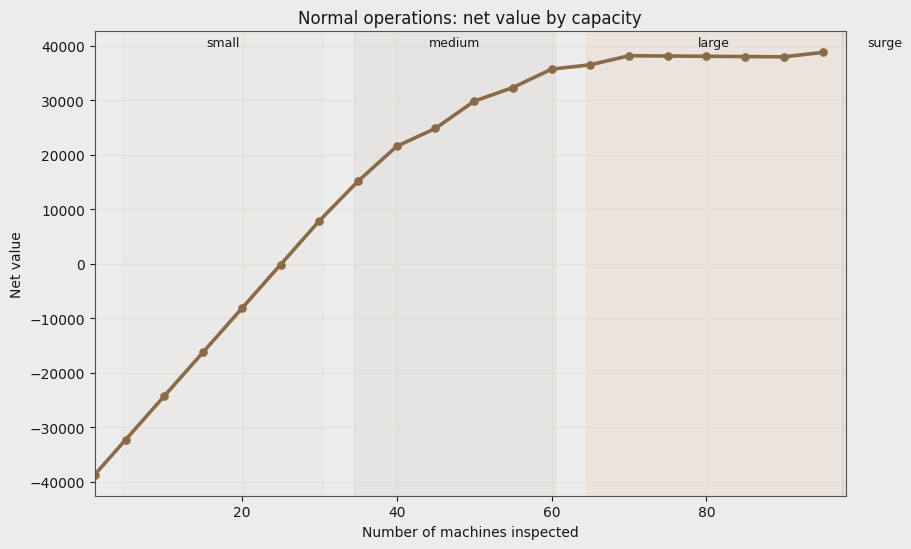

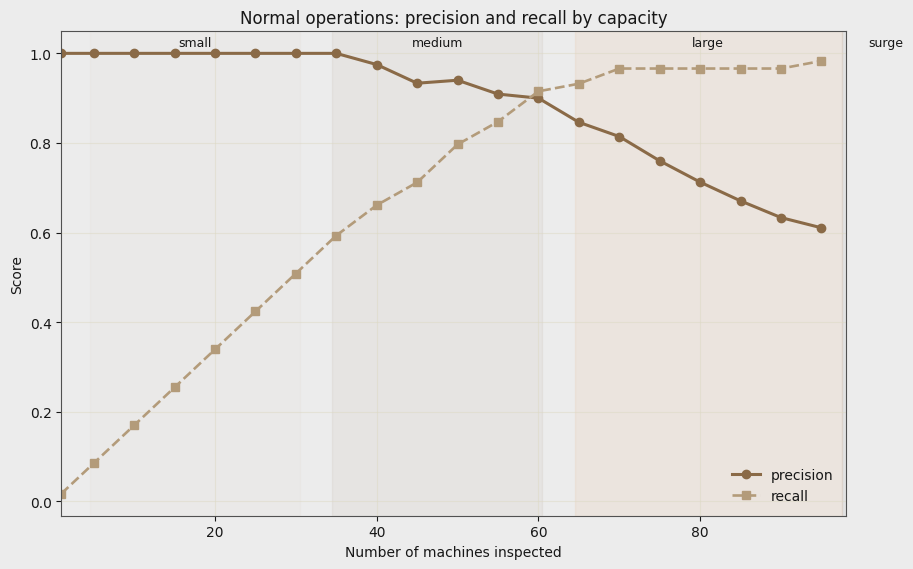

## Section 4  Emergency surge check

Model,Weight,Calibration,Threshold,Mean surge net value,Min surge net value
Extra Trees,balanced_x0.75,none,0.035,38352.503,38166.759


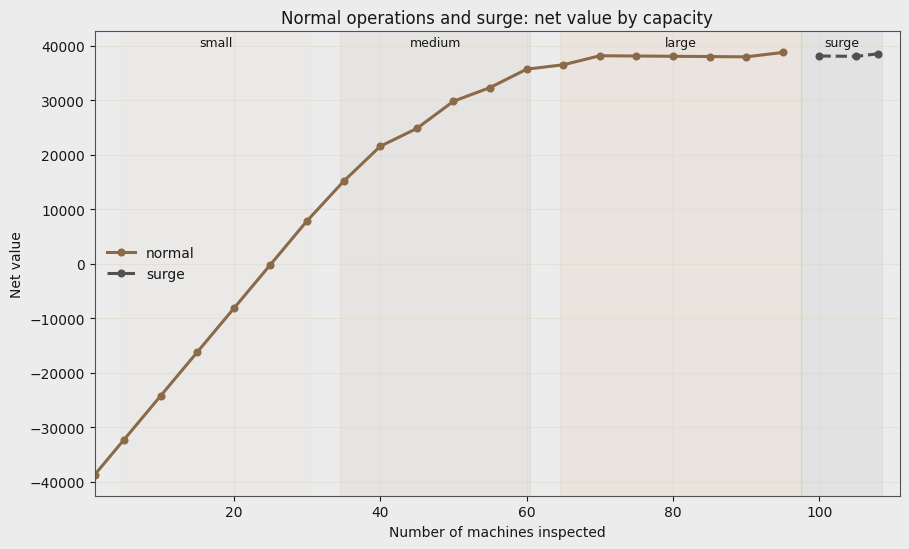

Interpretation: section 4 adds surge to the same capacity path so you can see where emergency mode begins.


## Final normal recommendation

Model,Weight,Threshold,Best capacity,Capacity label,Mean normal net value,Min normal net value,Best normal precision,Best normal recall
Extra Trees,none,0.029,95,large,15687.463,-38687.503,0.611,0.983


## Locked test summary

Model,Weight,Threshold,Test capacity,Test capacity label,Test net value,Test precision,Test recall,ROC AUC,PR AUC,Brier,ECE
Extra Trees,none,0.029,106,large,42176.527,0.557,1.000,0.979,0.966,0.057,0.086


## Queue preview only

Machine,Rank,Pred prob,Severity,Urgent,Fail,Action
23,1,0.999,High,True,1,Inspect now
97,2,0.999,High,True,1,Inspect now
111,3,0.999,High,True,1,Inspect now
11,4,0.998,High,True,1,Inspect now
133,5,0.997,High,True,1,Inspect now
115,6,0.997,High,True,1,Inspect now
61,7,0.996,High,True,1,Inspect now
82,8,0.996,High,True,1,Inspect now
75,9,0.996,High,True,1,Inspect now
123,10,0.994,High,True,1,Inspect now


## Done

Wrote locked_test_queue.csv
Wrote locked_test_summary.csv
Capacity is the main object.
Normal interpretation labels now use only three ranges: small, medium, large.
Surge remains 90% to 100% of urgent queue.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = str

try:
    from venn_abers import VennAbersCalibrator
    HAS_VENN_ABERS = True
except Exception:
    HAS_VENN_ABERS = False


# =========================================================
# SETTINGS
# =========================================================
RANDOM_STATE = 42
DATA_PATH = "/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv"
TARGET = "fail"

TEST_SIZE = 0.15
VALIDATION_SHARE_OF_REMAINDER = 0.17647058823529413

ROW_CHECK_COST = 10.0
BASE_MISSED_LOSS = 500.0
RECOVERY_RATE = 1.0
SEVERITY_SHRINK_ALPHA = 0.50

BOOTSTRAP_ROUNDS = 50
N_SPLITS = 4
TOP_CANDIDATES = 8
QUEUE_PREVIEW_ROWS = 10
CAPACITY_STEP = 5

SURGE_EXTRA_PER_CHECK = 5.0
SURGE_FIXED_ACTIVATION_COST = 100.0
SURGE_SHARE_START = 0.90

WEIGHT_STYLES = ["none", "balanced_x0.75", "balanced", "balanced_x1.25", "balanced_x1.5"]
MODELS = ["Logistic Regression", "Random Forest", "Extra Trees", "SVM RBF"]

MODE_USED = "capacity_first_three_normal_ranges_plus_surge"


# =========================================================
# NOTEBOOK STYLE
# =========================================================
PALETTE = {
    "bg": "#ececec",
    "grid": "#ddd9c3",
    "stone": "#c3c3c3",
    "sand": "#d6c6a8",
    "taupe": "#b39b7a",
    "cocoa": "#8a6a47",
    "copper": "#b66a2c",
    "amber": "#e46f0a",
    "slate": "#515151",
    "ink": "#171717",

    "small": "#d6c6a8",
    "medium": "#8a6a47",
    "large": "#e46f0a",
    "surge": "#515151",
}

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 160)


def apply_plot_style():
    plt.rcParams["figure.facecolor"] = PALETTE["bg"]
    plt.rcParams["axes.facecolor"] = PALETTE["bg"]
    plt.rcParams["savefig.facecolor"] = PALETTE["bg"]
    plt.rcParams["axes.edgecolor"] = PALETTE["slate"]
    plt.rcParams["axes.labelcolor"] = PALETTE["ink"]
    plt.rcParams["xtick.color"] = PALETTE["ink"]
    plt.rcParams["ytick.color"] = PALETTE["ink"]
    plt.rcParams["text.color"] = PALETTE["ink"]
    plt.rcParams["grid.color"] = PALETTE["grid"]
    plt.rcParams["grid.alpha"] = 0.50
    plt.rcParams["axes.titleweight"] = "regular"


apply_plot_style()


def show_title(text: str):
    try:
        display(Markdown(f"## {text}"))
    except Exception:
        print("\n" + text)


def style_table(df: pd.DataFrame, decimals: int = 3):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        out[num_cols] = out[num_cols].round(decimals)

    try:
        return (
            out.style
            .hide(axis="index")
            .format(precision=decimals)
            .set_table_styles([
                {"selector": "table", "props": [
                    ("background-color", PALETTE["bg"]),
                    ("color", PALETTE["ink"]),
                    ("border-collapse", "collapse"),
                    ("font-size", "14px"),
                    ("line-height", "1.25"),
                ]},
                {"selector": "th", "props": [
                    ("background-color", PALETTE["bg"]),
                    ("color", PALETTE["ink"]),
                    ("font-weight", "600"),
                    ("padding", "8px 10px"),
                    ("border-bottom", f"1px solid {PALETTE['stone']}"),
                    ("white-space", "normal"),
                    ("text-align", "left"),
                ]},
                {"selector": "td", "props": [
                    ("padding", "8px 10px"),
                    ("white-space", "nowrap"),
                    ("text-align", "left"),
                ]},
            ])
        )
    except Exception:
        return out


def show_table(df: pd.DataFrame, cols=None, rename=None, sort_by=None, ascending=False, decimals=3):
    out = df.copy()
    if cols is not None:
        out = out[cols].copy()
    if rename is not None:
        out = out.rename(columns=rename)
    if sort_by is not None:
        out = out.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    display(style_table(out, decimals=decimals))


# =========================================================
# HELPERS
# =========================================================
def clip_probs(p):
    return np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)


def current_surge_premium():
    return SURGE_EXTRA_PER_CHECK


def current_surge_fixed_cost():
    return SURGE_FIXED_ACTIVATION_COST


def make_capacity_grid(urgent_total: int, step: int = CAPACITY_STEP):
    urgent_total = int(max(urgent_total, 1))
    pts = list(range(step, urgent_total + 1, step))
    if 1 not in pts:
        pts = [1] + pts
    if urgent_total not in pts:
        pts.append(urgent_total)
    return sorted(set([p for p in pts if 1 <= p <= urgent_total]))


def surge_start_capacity(urgent_total: int) -> int:
    return max(1, int(math.ceil(urgent_total * SURGE_SHARE_START)))


def capacity_label(capacity: int, urgent_total: int) -> str:
    surge_start = surge_start_capacity(urgent_total)
    if capacity >= surge_start:
        return "surge"
    if capacity <= 30:
        return "small"
    if capacity <= 60:
        return "medium"
    return "large"


def capacity_label_table(urgent_total: int) -> pd.DataFrame:
    surge_start = surge_start_capacity(urgent_total)
    large_end = max(surge_start - 1, 65)
    return pd.DataFrame({
        "Label": ["small", "medium", "large", "surge"],
        "Rule": [
            "5 to 30",
            "35 to 60",
            f"65 to {large_end}",
            f"{surge_start} to {urgent_total}  (90% to 100% of urgent queue)",
        ],
    })


def calibration_stats(y_true, scores, n_bins=10):
    y_true = np.asarray(y_true, dtype=int)
    scores = clip_probs(scores)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(scores, bins[1:-1], right=True)

    ece = 0.0
    max_gap = 0.0
    n = len(scores)

    for b in range(n_bins):
        mask = bin_ids == b
        count = int(mask.sum())
        if count == 0:
            continue
        avg_pred = float(scores[mask].mean())
        avg_true = float(y_true[mask].mean())
        gap = abs(avg_true - avg_pred)
        ece += (count / n) * gap
        max_gap = max(max_gap, gap)

    return float(ece), float(max_gap)


# =========================================================
# SEVERITY
# =========================================================
def select_severity_features(X_train: pd.DataFrame, y_train: pd.Series, bootstrap_rounds: int):
    y_num = y_train.astype(float).reset_index(drop=True)
    X_part = X_train.reset_index(drop=True)
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []

    for col in X_part.columns:
        corr = pd.Series(X_part[col]).corr(y_num, method="spearman")
        corr = 0.0 if pd.isna(corr) else float(corr)

        n = len(X_part)
        boot_corrs = []
        for _ in range(bootstrap_rounds):
            idx = rng.integers(0, n, size=n)
            c = pd.Series(X_part.iloc[idx][col]).corr(pd.Series(y_num.iloc[idx]), method="spearman")
            c = 0.0 if pd.isna(c) else float(c)
            boot_corrs.append(c)

        rows.append({
            "feature": col,
            "spearman_with_fail": corr,
            "bootstrap_mean_abs_corr": float(np.mean(np.abs(boot_corrs))),
            "sign_agreement": float(np.mean(np.sign(boot_corrs) == np.sign(corr))) if corr != 0 else 1.0,
        })

    feature_table = pd.DataFrame(rows).sort_values(
        ["bootstrap_mean_abs_corr", "sign_agreement", "feature"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    keep = feature_table[
        (feature_table["bootstrap_mean_abs_corr"] >= 0.04) &
        (feature_table["sign_agreement"] >= 0.80)
    ].copy()

    if keep.empty:
        keep = feature_table.head(min(5, len(feature_table))).copy()

    keep = keep.sort_values(
        ["bootstrap_mean_abs_corr", "sign_agreement", "feature"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    selected = []
    for _, row in keep.iterrows():
        feat = row["feature"]
        if not selected:
            selected.append(feat)
            continue
        max_abs_corr = max(abs(X_train[feat].corr(X_train[s], method="spearman")) for s in selected)
        if pd.isna(max_abs_corr) or max_abs_corr < 0.95:
            selected.append(feat)

    keep = keep[keep["feature"].isin(selected)].copy().reset_index(drop=True)
    keep["weight"] = keep["bootstrap_mean_abs_corr"] / keep["bootstrap_mean_abs_corr"].sum()
    return feature_table, keep


class SeverityScorer:
    def __init__(self, keep_table: pd.DataFrame, shrink_alpha: float = 1.0):
        self.keep_table = keep_table.copy()
        self.shrink_alpha = float(shrink_alpha)
        self.scaler = StandardScaler()
        self.edges = None
        self.raw_multiplier_map = None
        self.multiplier_map = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        feats = self.keep_table["feature"].tolist()
        self.scaler.fit(X_train[feats])

        train_scores = self.score(X_train)
        self.edges = np.quantile(train_scores, [1 / 3, 2 / 3])

        labels = self.labels_from_scores(train_scores)
        tmp = pd.DataFrame({"severity": labels, "fail": y_train.values})
        overall_fail_rate = float(y_train.mean())

        rates = tmp.groupby("severity")["fail"].mean().reindex(["Low", "Medium", "High"])
        self.raw_multiplier_map = (rates / overall_fail_rate).to_dict()
        self.multiplier_map = {
            k: float(1.0 + self.shrink_alpha * (v - 1.0))
            for k, v in self.raw_multiplier_map.items()
        }
        return self

    def score(self, X_raw: pd.DataFrame) -> np.ndarray:
        feats = self.keep_table["feature"].tolist()
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_raw[feats]),
            columns=feats,
            index=X_raw.index,
        )

        score = np.zeros(len(X_scaled), dtype=float)
        for _, row in self.keep_table.iterrows():
            sign = 1.0 if row["spearman_with_fail"] >= 0 else -1.0
            score += X_scaled[row["feature"]].to_numpy(dtype=float) * float(row["weight"]) * sign
        return score

    def labels_from_scores(self, scores: np.ndarray) -> pd.Series:
        bins = np.digitize(scores, bins=self.edges, right=True)
        return pd.Series(np.array(["Low", "Medium", "High"])[bins])

    def labels(self, X_raw: pd.DataFrame) -> pd.Series:
        return self.labels_from_scores(self.score(X_raw))

    def value_table(self, severity_labels: pd.Series) -> pd.DataFrame:
        sev_mult = pd.Series(severity_labels).map(self.multiplier_map).astype(float).values
        row_missed_loss = BASE_MISSED_LOSS * sev_mult
        row_saved_value = row_missed_loss * RECOVERY_RATE
        return pd.DataFrame({
            "row_check_cost": np.full(len(severity_labels), ROW_CHECK_COST, dtype=float),
            "row_missed_loss": row_missed_loss,
            "row_saved_value": row_saved_value,
        })


# =========================================================
# MODELS
# =========================================================
def make_class_weight(style: str, y_train: pd.Series):
    if style == "none":
        return None
    pos_weight = (len(y_train) - int(y_train.sum())) / max(int(y_train.sum()), 1)
    mult = {
        "balanced_x0.75": 0.75,
        "balanced": 1.00,
        "balanced_x1.25": 1.25,
        "balanced_x1.5": 1.50,
    }[style]
    return {0: 1.0, 1: float(mult * pos_weight)}


def build_base_estimator(model_name: str, class_weight):
    if model_name == "Logistic Regression":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
                class_weight=class_weight,
            )),
        ])
    if model_name == "Random Forest":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=220,
                min_samples_leaf=2,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])
    if model_name == "Extra Trees":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=280,
                min_samples_leaf=2,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])
    if model_name == "SVM RBF":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                probability=True,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
            )),
        ])
    raise ValueError(f"Unknown model name: {model_name}")


def cv_model_search(X_train: pd.DataFrame, y_train: pd.Series) -> pd.DataFrame:
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for model_name in MODELS:
        for weight_style in WEIGHT_STYLES:
            class_weight = make_class_weight(weight_style, y_train)
            fold_roc, fold_pr = [], []

            for fit_idx, score_idx in cv.split(X_train, y_train):
                X_fit = X_train.iloc[fit_idx]
                y_fit = y_train.iloc[fit_idx]
                X_score = X_train.iloc[score_idx]
                y_score = y_train.iloc[score_idx]

                model = build_base_estimator(model_name, class_weight)
                model.fit(X_fit, y_fit)
                prob = clip_probs(model.predict_proba(X_score)[:, 1])

                fold_roc.append(roc_auc_score(y_score, prob))
                fold_pr.append(average_precision_score(y_score, prob))

            rows.append({
                "model": model_name,
                "weight_style": weight_style,
                "cv_pr_auc_mean": float(np.mean(fold_pr)),
                "cv_pr_auc_std": float(np.std(fold_pr)),
                "cv_roc_auc_mean": float(np.mean(fold_roc)),
                "cv_roc_auc_std": float(np.std(fold_roc)),
            })

    return pd.DataFrame(rows).sort_values(
        ["cv_pr_auc_mean", "cv_roc_auc_mean", "cv_pr_auc_std", "cv_roc_auc_std"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)


def build_oof_raw_scores(X_train, y_train, model_name, weight_style):
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X_train), dtype=float)

    for fit_idx, hold_idx in cv.split(X_train, y_train):
        X_fit = X_train.iloc[fit_idx]
        y_fit = y_train.iloc[fit_idx]
        X_hold = X_train.iloc[hold_idx]
        class_weight = make_class_weight(weight_style, y_fit)
        model = build_base_estimator(model_name, class_weight)
        model.fit(X_fit, y_fit)
        oof[hold_idx] = clip_probs(model.predict_proba(X_hold)[:, 1])

    return oof


# =========================================================
# CALIBRATION
# =========================================================
def fit_temperature_scaler(raw_scores, y_true):
    p = clip_probs(raw_scores)
    logits = np.log(p / (1.0 - p))
    y = np.asarray(y_true, dtype=float)

    def objective(temp):
        temp = max(float(temp), 1e-3)
        scaled = 1.0 / (1.0 + np.exp(-logits / temp))
        scaled = clip_probs(scaled)
        return float(-np.mean(y * np.log(scaled) + (1.0 - y) * np.log(1.0 - scaled)))

    return float(minimize_scalar(objective, bounds=(0.05, 10.0), method="bounded").x)


def apply_temperature_scaler(temp, raw_scores):
    p = clip_probs(raw_scores)
    logits = np.log(p / (1.0 - p))
    scaled = 1.0 / (1.0 + np.exp(-logits / max(float(temp), 1e-3)))
    return clip_probs(scaled)


def fit_histogram_binning(raw_scores, y_true, n_bins=5):
    p = clip_probs(raw_scores)
    y = np.asarray(y_true, dtype=float)

    quantiles = np.linspace(0.0, 1.0, n_bins + 1)
    edges = np.quantile(p, quantiles)
    edges[0], edges[-1] = 0.0, 1.0

    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = min(edges[i - 1] + 1e-8, 1.0)

    bin_ids = np.digitize(p, edges[1:-1], right=True)
    global_rate = float(y.mean())
    bin_rates = np.array([
        global_rate if (bin_ids == b).sum() == 0 else float(y[bin_ids == b].mean())
        for b in range(n_bins)
    ], dtype=float)

    return {"edges": edges, "bin_rates": bin_rates}


def apply_histogram_binning(calibrator, raw_scores):
    p = clip_probs(raw_scores)
    bin_ids = np.digitize(p, calibrator["edges"][1:-1], right=True)
    return clip_probs(np.array([calibrator["bin_rates"][b] for b in bin_ids], dtype=float))


def fit_venn_abers_model(model_name, weight_style, X_train, y_train):
    class_weight = make_class_weight(weight_style, y_train)
    estimator = build_base_estimator(model_name, class_weight)
    va = VennAbersCalibrator(
        estimator=estimator,
        inductive=True,
        cal_size=0.2,
        random_state=RANDOM_STATE,
    )
    va.fit(X_train, y_train)
    return va


def choose_calibration(X_train, y_train, X_validation, y_validation, model_name, weight_style):
    oof_raw = build_oof_raw_scores(
        X_train.reset_index(drop=True),
        y_train.reset_index(drop=True),
        model_name,
        weight_style,
    )

    class_weight = make_class_weight(weight_style, y_train)
    full_model = build_base_estimator(model_name, class_weight)
    full_model.fit(X_train, y_train)
    validation_raw = clip_probs(full_model.predict_proba(X_validation)[:, 1])

    candidates = {
        "none": validation_raw,
        "temperature": apply_temperature_scaler(
            fit_temperature_scaler(oof_raw, y_train.reset_index(drop=True).values),
            validation_raw,
        ),
        "histogram_5bin": apply_histogram_binning(
            fit_histogram_binning(oof_raw, y_train.reset_index(drop=True).values, n_bins=5),
            validation_raw,
        ),
    }

    if HAS_VENN_ABERS:
        va = fit_venn_abers_model(
            model_name,
            weight_style,
            X_train.reset_index(drop=True),
            y_train.reset_index(drop=True),
        )
        candidates["venn_abers"] = clip_probs(va.predict_proba(X_validation)[:, 1])

    rows = []
    for method, prob in candidates.items():
        ece, max_gap = calibration_stats(y_validation, prob)
        rows.append({
            "calibration": method,
            "validation_brier": float(brier_score_loss(y_validation, prob)),
            "validation_ece": float(ece),
            "validation_max_gap": float(max_gap),
        })

    summary = pd.DataFrame(rows).sort_values(
        ["validation_brier", "validation_ece", "validation_max_gap"],
        ascending=[True, True, True],
    ).reset_index(drop=True)

    winning_calibration = str(summary.iloc[0]["calibration"])
    return summary, winning_calibration, full_model, candidates[winning_calibration]


# =========================================================
# VALUE TABLES
# =========================================================
def build_threshold_table(y_true, scores, value_table):
    table = value_table.copy().reset_index(drop=True)
    table["actual_failure"] = np.asarray(y_true, dtype=int)
    table["score"] = np.asarray(scores, dtype=float)
    table = table.sort_values("score", ascending=False).reset_index(drop=True)

    total_failures = max(int(table["actual_failure"].sum()), 1)
    rows = []

    for k in range(1, len(table) + 1):
        urgent = table.iloc[:k]
        backlog = table.iloc[k:]

        saved_failure_value = float(urgent.loc[urgent["actual_failure"] == 1, "row_saved_value"].sum())
        check_cost = float(urgent["row_check_cost"].sum())
        missed_failure_cost = float(backlog.loc[backlog["actual_failure"] == 1, "row_missed_loss"].sum())
        tp = int(urgent["actual_failure"].sum())

        rows.append({
            "threshold": float(table.loc[k - 1, "score"]),
            "urgent_total": int(k),
            "net_value": saved_failure_value - check_cost - missed_failure_cost,
            "precision": tp / max(k, 1),
            "recall": tp / total_failures,
        })

    return pd.DataFrame(rows)


def build_capacity_table(
    y_true,
    scores,
    value_table,
    threshold,
    surge_mode_active=False,
    surge_extra_per_check=0.0,
    surge_fixed_activation_cost=0.0,
):
    queue = value_table.copy().reset_index(drop=True)
    queue["actual_failure"] = np.asarray(y_true, dtype=int)
    queue["score"] = np.asarray(scores, dtype=float)
    queue = queue[queue["score"] >= threshold].sort_values("score", ascending=False).reset_index(drop=True)

    total_urgent_failures = max(int(queue["actual_failure"].sum()), 1)
    rows = []

    for k in range(1, len(queue) + 1):
        do_today = queue.iloc[:k]
        backlog = queue.iloc[k:]

        saved_failure_value = float(do_today.loc[do_today["actual_failure"] == 1, "row_saved_value"].sum())
        base_check_cost = float(do_today["row_check_cost"].sum())
        surge_premium_cost = float(k * surge_extra_per_check) if surge_mode_active else 0.0
        surge_activation_cost = float(surge_fixed_activation_cost) if surge_mode_active and k > 0 else 0.0
        total_check_cost = base_check_cost + surge_premium_cost + surge_activation_cost
        missed_failure_cost = float(backlog.loc[backlog["actual_failure"] == 1, "row_missed_loss"].sum())

        rows.append({
            "capacity": int(k),
            "base_check_cost": float(base_check_cost),
            "surge_premium_cost": float(surge_premium_cost),
            "surge_activation_cost": float(surge_activation_cost),
            "total_check_cost": float(total_check_cost),
            "missed_failure_cost": float(missed_failure_cost),
            "net_value": float(saved_failure_value - total_check_cost - missed_failure_cost),
            "today_precision": float(do_today["actual_failure"].mean()),
            "today_recall_within_urgent_pool": float(do_today["actual_failure"].sum() / total_urgent_failures),
        })

    return queue, pd.DataFrame(rows)


def evaluate_candidate_capacity_first(X_train, y_train, X_validation, y_validation, validation_values, model_name, weight_style):
    calibration_summary, winning_calibration, _, validation_prob = choose_calibration(
        X_train, y_train, X_validation, y_validation, model_name, weight_style
    )

    threshold_table = build_threshold_table(y_validation, validation_prob, validation_values)
    best_threshold_row = threshold_table.sort_values(
        ["net_value", "recall", "precision"],
        ascending=[False, False, False],
    ).iloc[0]
    candidate_threshold = float(best_threshold_row["threshold"])

    queue, _ = build_capacity_table(
        y_validation,
        validation_prob,
        validation_values,
        candidate_threshold,
        surge_mode_active=False,
        surge_extra_per_check=0.0,
        surge_fixed_activation_cost=0.0,
    )

    urgent_total = len(queue)
    grid = make_capacity_grid(urgent_total)

    sampled_rows = []
    for k in grid:
        is_surge = k >= surge_start_capacity(urgent_total)
        do_today = queue.iloc[:k]
        backlog = queue.iloc[k:]

        saved_failure_value = float(do_today.loc[do_today["actual_failure"] == 1, "row_saved_value"].sum())
        base_check_cost = float(do_today["row_check_cost"].sum())
        surge_premium_cost = float(k * current_surge_premium()) if is_surge else 0.0
        surge_activation_cost = float(current_surge_fixed_cost()) if is_surge and k > 0 else 0.0
        total_check_cost = base_check_cost + surge_premium_cost + surge_activation_cost
        missed_failure_cost = float(backlog.loc[backlog["actual_failure"] == 1, "row_missed_loss"].sum())
        total_urgent_failures = max(int(queue["actual_failure"].sum()), 1)
        tp = int(do_today["actual_failure"].sum())

        sampled_rows.append({
            "capacity": int(k),
            "urgent_total": int(urgent_total),
            "label": capacity_label(k, urgent_total),
            "base_check_cost": base_check_cost,
            "surge_premium_cost": surge_premium_cost,
            "surge_activation_cost": surge_activation_cost,
            "total_check_cost": total_check_cost,
            "missed_failure_cost": missed_failure_cost,
            "net_value": saved_failure_value - total_check_cost - missed_failure_cost,
            "today_precision": tp / max(k, 1),
            "today_recall_within_urgent_pool": tp / total_urgent_failures,
            "model": model_name,
            "weight_style": weight_style,
            "calibration": winning_calibration,
            "threshold": candidate_threshold,
            "validation_brier": float(calibration_summary.iloc[0]["validation_brier"]),
            "validation_ece": float(calibration_summary.iloc[0]["validation_ece"]),
            "validation_max_gap": float(calibration_summary.iloc[0]["validation_max_gap"]),
        })

    cap_df = pd.DataFrame(sampled_rows)
    normal_df = cap_df[cap_df["label"] != "surge"].copy()
    surge_df = cap_df[cap_df["label"] == "surge"].copy()

    normal_best_row = normal_df.sort_values(
        ["net_value", "today_precision", "today_recall_within_urgent_pool"],
        ascending=[False, False, False],
    ).iloc[0]

    summary = {
        "model": model_name,
        "weight_style": weight_style,
        "calibration": winning_calibration,
        "threshold": candidate_threshold,
        "urgent_total": int(urgent_total),
        "normal_mean_net_value": float(normal_df["net_value"].mean()),
        "normal_min_net_value": float(normal_df["net_value"].min()),
        "normal_best_capacity": int(normal_best_row["capacity"]),
        "normal_best_label": str(normal_best_row["label"]),
        "normal_best_net_value": float(normal_best_row["net_value"]),
        "normal_best_precision": float(normal_best_row["today_precision"]),
        "normal_best_recall": float(normal_best_row["today_recall_within_urgent_pool"]),
        "surge_mean_net_value": None if surge_df.empty else float(surge_df["net_value"].mean()),
        "surge_min_net_value": None if surge_df.empty else float(surge_df["net_value"].min()),
    }

    return cap_df, summary


def fit_final_calibrator(X_train_final, y_train_final, model_name, weight_style, calibration_name):
    if calibration_name == "none":
        return None
    if calibration_name == "temperature":
        oof_raw = build_oof_raw_scores(
            X_train_final.reset_index(drop=True),
            y_train_final.reset_index(drop=True),
            model_name,
            weight_style,
        )
        return fit_temperature_scaler(oof_raw, y_train_final.reset_index(drop=True).values)
    if calibration_name == "histogram_5bin":
        oof_raw = build_oof_raw_scores(
            X_train_final.reset_index(drop=True),
            y_train_final.reset_index(drop=True),
            model_name,
            weight_style,
        )
        return fit_histogram_binning(oof_raw, y_train_final.reset_index(drop=True).values, n_bins=5)
    if calibration_name == "venn_abers":
        return fit_venn_abers_model(
            model_name,
            weight_style,
            X_train_final.reset_index(drop=True),
            y_train_final.reset_index(drop=True),
        )
    raise ValueError(f"Unknown calibration: {calibration_name}")


def apply_final_calibration(calibration_name, calibrator, raw_scores, X_test=None):
    if calibration_name == "none":
        return clip_probs(raw_scores)
    if calibration_name == "temperature":
        return apply_temperature_scaler(calibrator, raw_scores)
    if calibration_name == "histogram_5bin":
        return apply_histogram_binning(calibrator, raw_scores)
    if calibration_name == "venn_abers":
        return clip_probs(calibrator.predict_proba(X_test)[:, 1])
    raise ValueError(f"Unknown calibration: {calibration_name}")


# =========================================================
# PLOTS
# =========================================================
def add_capacity_spans(ax, urgent_total: int):
    surge_start = surge_start_capacity(urgent_total)
    large_end = max(surge_start - 1, 65)
    spans = [
        ("small", 5, 30),
        ("medium", 35, 60),
        ("large", 65, large_end),
        ("surge", surge_start, urgent_total),
    ]
    for label, left, right in spans:
        if left > urgent_total:
            continue
        right = min(right, urgent_total)
        if right < left:
            continue
        ax.axvspan(left - 0.5, right + 0.5, color=PALETTE[label], alpha=0.06)
        ax.text(
            (left + right) / 2,
            0.99,
            label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            color=PALETTE["ink"],
        )


def plot_normal_net_value(best_capacity_df):
    normal = best_capacity_df[best_capacity_df["label"] != "surge"].copy().sort_values("capacity")
    plt.figure(figsize=(9.2, 5.6))
    ax = plt.gca()

    add_capacity_spans(ax, int(best_capacity_df["urgent_total"].max()))

    plt.plot(
        normal["capacity"],
        normal["net_value"],
        marker="o",
        linewidth=2.6,
        markersize=5.2,
        color=PALETTE["cocoa"],
    )

    plt.xlim(max(1, normal["capacity"].min() - 3), normal["capacity"].max() + 3)
    plt.xlabel("Number of machines inspected")
    plt.ylabel("Net value")
    plt.title("Normal operations: net value by capacity")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_normal_precision_recall(best_capacity_df):
    normal = best_capacity_df[best_capacity_df["label"] != "surge"].copy().sort_values("capacity")
    plt.figure(figsize=(9.2, 5.8))
    ax = plt.gca()

    add_capacity_spans(ax, int(best_capacity_df["urgent_total"].max()))

    plt.plot(
        normal["capacity"],
        normal["today_precision"],
        marker="o",
        linewidth=2.2,
        color=PALETTE["cocoa"],
        label="precision",
    )
    plt.plot(
        normal["capacity"],
        normal["today_recall_within_urgent_pool"],
        marker="s",
        linewidth=1.9,
        linestyle="--",
        color=PALETTE["taupe"],
        label="recall",
    )

    plt.xlim(max(1, normal["capacity"].min() - 3), normal["capacity"].max() + 3)
    plt.xlabel("Number of machines inspected")
    plt.ylabel("Score")
    plt.title("Normal operations: precision and recall by capacity")
    plt.grid(True)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def plot_all_regimes_net_value(best_capacity_df):
    all_rows = best_capacity_df.sort_values("capacity")
    plt.figure(figsize=(9.2, 5.6))
    ax = plt.gca()

    add_capacity_spans(ax, int(best_capacity_df["urgent_total"].max()))

    normal = all_rows[all_rows["label"] != "surge"]
    surge = all_rows[all_rows["label"] == "surge"]

    plt.plot(
        normal["capacity"],
        normal["net_value"],
        marker="o",
        linewidth=2.2,
        markersize=4.8,
        color=PALETTE["cocoa"],
        label="normal",
    )
    if len(surge) > 0:
        plt.plot(
            surge["capacity"],
            surge["net_value"],
            marker="o",
            linewidth=2.2,
            linestyle="--",
            markersize=4.8,
            color=PALETTE["surge"],
            label="surge",
        )

    plt.xlim(max(1, all_rows["capacity"].min() - 3), all_rows["capacity"].max() + 3)
    plt.xlabel("Number of machines inspected")
    plt.ylabel("Net value")
    plt.title("Normal operations and surge: net value by capacity")
    plt.grid(True)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================
def main():
    data = pd.read_csv(DATA_PATH).drop_duplicates().reset_index(drop=True)
    if TARGET not in data.columns:
        raise ValueError("The dataset must contain a 'fail' column.")

    feature_cols = [c for c in data.columns if c != TARGET and pd.api.types.is_numeric_dtype(data[c])]
    X = data[feature_cols].copy()
    y = data[TARGET].astype(int).copy()

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_validation, y_train, y_validation = train_test_split(
        X_temp, y_temp,
        test_size=VALIDATION_SHARE_OF_REMAINDER,
        stratify=y_temp,
        random_state=RANDOM_STATE,
    )

    _, severity_keep = select_severity_features(X_train, y_train, BOOTSTRAP_ROUNDS)
    severity_scorer = SeverityScorer(severity_keep, shrink_alpha=SEVERITY_SHRINK_ALPHA).fit(X_train, y_train)
    validation_values = severity_scorer.value_table(severity_scorer.labels(X_validation))

    search_results = cv_model_search(X_train.reset_index(drop=True), y_train.reset_index(drop=True))
    top_candidates = search_results.head(min(TOP_CANDIDATES, len(search_results))).copy()

    candidate_curves = []
    candidate_summaries = []

    for _, candidate in top_candidates.iterrows():
        cap_df, summary = evaluate_candidate_capacity_first(
            X_train=X_train,
            y_train=y_train,
            X_validation=X_validation,
            y_validation=y_validation,
            validation_values=validation_values,
            model_name=str(candidate["model"]),
            weight_style=str(candidate["weight_style"]),
        )
        candidate_curves.append(cap_df)
        candidate_summaries.append(summary)

    if not candidate_curves:
        raise ValueError("No candidate curves were created.")

    candidate_curves_df = pd.concat(candidate_curves, axis=0).reset_index(drop=True)
    candidate_summary_df = pd.DataFrame(candidate_summaries).sort_values(
        ["normal_mean_net_value", "normal_min_net_value", "normal_best_net_value"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    best_normal = candidate_summary_df.iloc[0]
    best_capacity_df = candidate_curves_df[
        (candidate_curves_df["model"] == best_normal["model"]) &
        (candidate_curves_df["weight_style"] == best_normal["weight_style"]) &
        (candidate_curves_df["calibration"] == best_normal["calibration"]) &
        (candidate_curves_df["threshold"] == best_normal["threshold"])
    ].copy().sort_values("capacity").reset_index(drop=True)

    surge_candidates = candidate_summary_df[candidate_summary_df["surge_mean_net_value"].notna()].copy()
    best_surge = None if surge_candidates.empty else surge_candidates.sort_values(
        ["surge_mean_net_value", "surge_min_net_value"],
        ascending=[False, False],
    ).iloc[0]

    urgent_total_best = int(best_normal["urgent_total"])

    show_title("Section 1  Study question and setup")
    assumptions_table = pd.DataFrame({
        "Item": [
            "Rows in dataset",
            "Failure rate",
            "Target column",
            "Train split approach",
            "Check cost per machine",
            "Base missed failure loss",
            "Recovery rate",
            "Severity shrink alpha",
            "Surge extra cost per check",
            "Surge fixed activation cost",
            "Main x axis meaning",
            "Capacity labels used for interpretation",
            "Surge starts around",
            "Model families tested",
            "Weight styles tested",
        ],
        "Value": [
            f"{len(data)}",
            f"{y.mean():.3f}",
            TARGET,
            "train / validation / test",
            f"{ROW_CHECK_COST:.1f}",
            f"{BASE_MISSED_LOSS:.1f}",
            f"{RECOVERY_RATE:.1f}",
            f"{SEVERITY_SHRINK_ALPHA:.2f}",
            f"{current_surge_premium():.1f}",
            f"{current_surge_fixed_cost():.1f}",
            "number of machines inspected",
            "small, medium, large, surge",
            f"starts at {surge_start_capacity(urgent_total_best)} machines in this run",
            ", ".join(MODELS),
            ", ".join(WEIGHT_STYLES),
        ],
    })
    show_table(assumptions_table)
    show_table(capacity_label_table(urgent_total_best))

    show_title("Section 2  Method and fixed rule")
    print("Capacity is the main object.")
    print("Labels are only used to interpret the capacity path.")
    print("Fixed urgent threshold within each candidate.")
    print("Severity learned from training only.")
    print()
    show_table(
        search_results.head(8),
        cols=["model", "weight_style", "cv_pr_auc_mean", "cv_pr_auc_std", "cv_roc_auc_mean", "cv_roc_auc_std"],
        rename={
            "model": "Model",
            "weight_style": "Weight",
            "cv_pr_auc_mean": "PR AUC",
            "cv_pr_auc_std": "PR std",
            "cv_roc_auc_mean": "ROC AUC",
            "cv_roc_auc_std": "ROC std",
        },
    )

    show_title("Section 3  Normal operations results")
    normal_summary_table = pd.DataFrame([{
        "Model": best_normal["model"],
        "Weight": best_normal["weight_style"],
        "Calibration": best_normal["calibration"],
        "Threshold": best_normal["threshold"],
        "Urgent queue size": int(best_normal["urgent_total"]),
        "Best normal capacity": int(best_normal["normal_best_capacity"]),
        "Best normal label": best_normal["normal_best_label"],
        "Best normal net value": float(best_normal["normal_best_net_value"]),
        "Mean normal net value": float(best_normal["normal_mean_net_value"]),
        "Min normal net value": float(best_normal["normal_min_net_value"]),
        "Best normal precision": float(best_normal["normal_best_precision"]),
        "Best normal recall": float(best_normal["normal_best_recall"]),
    }])
    show_table(normal_summary_table)

    plot_normal_net_value(best_capacity_df)
    plot_normal_precision_recall(best_capacity_df)

    show_title("Section 4  Emergency surge check")
    if best_surge is None:
        print("Surge not available in this run.")
    else:
        surge_summary_table = pd.DataFrame([{
            "Model": best_surge["model"],
            "Weight": best_surge["weight_style"],
            "Calibration": best_surge["calibration"],
            "Threshold": best_surge["threshold"],
            "Mean surge net value": float(best_surge["surge_mean_net_value"]),
            "Min surge net value": float(best_surge["surge_min_net_value"]),
        }])
        show_table(surge_summary_table)
        plot_all_regimes_net_value(best_capacity_df)
        print("Interpretation: section 4 adds surge to the same capacity path so you can see where emergency mode begins.")

    selected_capacity = int(best_normal["normal_best_capacity"])
    locked_capacity_share = selected_capacity / max(int(best_normal["urgent_total"]), 1)

    X_train_final = pd.concat([X_train, X_validation], axis=0).reset_index(drop=True)
    y_train_final = pd.concat([y_train, y_validation], axis=0).reset_index(drop=True)

    _, final_keep = select_severity_features(X_train_final, y_train_final, BOOTSTRAP_ROUNDS)
    final_scorer = SeverityScorer(final_keep, shrink_alpha=SEVERITY_SHRINK_ALPHA).fit(X_train_final, y_train_final)
    test_values = final_scorer.value_table(final_scorer.labels(X_test))

    winning_model_name = str(best_normal["model"])
    winning_weight_style = str(best_normal["weight_style"])
    winning_calibration = str(best_normal["calibration"])
    locked_threshold = float(best_normal["threshold"])

    winning_class_weight = make_class_weight(winning_weight_style, y_train_final)
    final_model = build_base_estimator(winning_model_name, winning_class_weight)
    final_model.fit(X_train_final, y_train_final)

    test_raw = clip_probs(final_model.predict_proba(X_test)[:, 1])
    final_calibrator = fit_final_calibrator(
        X_train_final, y_train_final, winning_model_name, winning_weight_style, winning_calibration
    )
    test_prob = apply_final_calibration(winning_calibration, final_calibrator, test_raw, X_test=X_test)

    test_ece, _ = calibration_stats(y_test, test_prob)
    test_queue, test_capacity_table = build_capacity_table(
        y_test,
        test_prob,
        test_values,
        locked_threshold,
        surge_mode_active=False,
        surge_extra_per_check=0.0,
        surge_fixed_activation_cost=0.0,
    )

    locked_test_capacity = max(1, int(round(locked_capacity_share * len(test_queue))))
    locked_test_capacity = min(locked_test_capacity, len(test_queue))
    locked_test_row = test_capacity_table.loc[test_capacity_table["capacity"] == locked_test_capacity].iloc[0]

    final_normal_table = pd.DataFrame([{
        "Model": winning_model_name,
        "Weight": winning_weight_style,
        "Threshold": locked_threshold,
        "Best capacity": selected_capacity,
        "Capacity label": capacity_label(selected_capacity, int(best_normal["urgent_total"])),
        "Mean normal net value": float(best_normal["normal_mean_net_value"]),
        "Min normal net value": float(best_normal["normal_min_net_value"]),
        "Best normal precision": float(best_normal["normal_best_precision"]),
        "Best normal recall": float(best_normal["normal_best_recall"]),
    }])
    show_title("Final normal recommendation")
    show_table(final_normal_table)

    locked_test_summary = pd.DataFrame([{
        "Model": winning_model_name,
        "Weight": winning_weight_style,
        "Threshold": locked_threshold,
        "Test capacity": int(locked_test_capacity),
        "Test capacity label": capacity_label(locked_test_capacity, len(test_queue)),
        "Test net value": float(locked_test_row["net_value"]),
        "Test precision": float(locked_test_row["today_precision"]),
        "Test recall": float(locked_test_row["today_recall_within_urgent_pool"]),
        "ROC AUC": float(roc_auc_score(y_test, test_prob)),
        "PR AUC": float(average_precision_score(y_test, test_prob)),
        "Brier": float(brier_score_loss(y_test, test_prob)),
        "ECE": float(test_ece),
    }])
    show_title("Locked test summary")
    show_table(locked_test_summary)

    output = X_test.copy().reset_index(drop=True)
    output.insert(0, "machine_id", np.arange(1, len(output) + 1))
    output["mode_used"] = MODE_USED
    output["selected_model"] = winning_model_name
    output["selected_weight"] = winning_weight_style
    output["selected_threshold"] = locked_threshold
    output["selected_capacity"] = selected_capacity
    output["selected_capacity_label"] = capacity_label(selected_capacity, int(best_normal["urgent_total"]))
    output["actual_fail"] = y_test.reset_index(drop=True).values
    output["predicted_failure_probability"] = test_prob
    output["severity_band"] = final_scorer.labels(X_test).values
    output["is_urgent"] = output["predicted_failure_probability"] >= locked_threshold
    output = output.sort_values("predicted_failure_probability", ascending=False).reset_index(drop=True)
    output["queue_rank"] = np.arange(1, len(output) + 1)
    output["action"] = "Monitor"
    output.loc[(output["is_urgent"]) & (output["queue_rank"] <= locked_test_capacity), "action"] = "Inspect now"
    output.loc[(output["is_urgent"]) & (output["queue_rank"] > locked_test_capacity), "action"] = "Backlog urgent"

    test_summary_file = pd.DataFrame([{
        "mode_used": MODE_USED,
        "selected_model": winning_model_name,
        "selected_weight": winning_weight_style,
        "selected_threshold": locked_threshold,
        "selected_capacity": selected_capacity,
        "selected_capacity_label": capacity_label(selected_capacity, int(best_normal["urgent_total"])),
        "test_urgent_total": int(len(test_queue)),
        "test_capacity": int(locked_test_capacity),
        "test_capacity_label": capacity_label(locked_test_capacity, len(test_queue)),
        "test_roc_auc": float(roc_auc_score(y_test, test_prob)),
        "test_pr_auc": float(average_precision_score(y_test, test_prob)),
        "test_brier": float(brier_score_loss(y_test, test_prob)),
        "test_ece": float(test_ece),
        "test_base_check_cost": float(locked_test_row["base_check_cost"]),
        "test_total_check_cost": float(locked_test_row["total_check_cost"]),
        "test_missed_failure_cost": float(locked_test_row["missed_failure_cost"]),
        "test_capacity_net_value": float(locked_test_row["net_value"]),
        "test_today_precision": float(locked_test_row["today_precision"]),
        "test_today_recall_within_urgent_pool": float(locked_test_row["today_recall_within_urgent_pool"]),
        "surge_extra_per_check": current_surge_premium(),
        "surge_fixed_activation_cost": current_surge_fixed_cost(),
    }])

    output.to_csv("locked_test_queue.csv", index=False)
    test_summary_file.to_csv("locked_test_summary.csv", index=False)

    show_title("Queue preview only")
    show_table(
        output.head(QUEUE_PREVIEW_ROWS),
        cols=[
            "machine_id",
            "queue_rank",
            "predicted_failure_probability",
            "severity_band",
            "is_urgent",
            "actual_fail",
            "action",
        ],
        rename={
            "machine_id": "Machine",
            "queue_rank": "Rank",
            "predicted_failure_probability": "Pred prob",
            "severity_band": "Severity",
            "is_urgent": "Urgent",
            "actual_fail": "Fail",
            "action": "Action",
        },
    )

    show_title("Done")
    print("Wrote locked_test_queue.csv")
    print("Wrote locked_test_summary.csv")
    print("Capacity is the main object.")
    print("Normal interpretation labels now use only three ranges: small, medium, large.")
    print("Surge remains 90% to 100% of urgent queue.")


if __name__ == "__main__":
    main()

Yes. The `3.5` looks weak unless your `10` check cost already has a big non labor part.

Best way to think about it

Your surge premium should be the extra cost above normal checking cost.

So not this:

normal check cost + full overtime wage

but this:

extra premium only = overtime uplift on the labor part

A defensible formula is:

`surge_extra_per_check = labor_share_of_check_cost × overtime_uplift`

If federal overtime applies, the wage rate is at least 1.5 times regular pay, so the extra uplift is 0.5 times the labor portion, not 1.5 times it. ([DOL][1])

So with your current numbers:

`row_check_cost = 10`

then

`surge_extra_per_check = 10 × labor_share × 0.5`

That gives:

if labor share is 50%, surge extra = `2.5`
if labor share is 70%, surge extra = `3.5`
if labor share is 80%, surge extra = `4.0`
if labor share is 100%, surge extra = `5.0`

So `3.5` is exactly the case where about 70% of the `10` check cost is labor. That is not crazy, but it is only one assumption, not a proven value from your dataset. ([DOL][2])

Why it may still be too low

In your notebook, `500` is the base missed loss, while the surge extra is only `3.5`. That means the surge premium is only 35% of normal check cost and only 0.7% of base missed loss. So even after adding surge cost, the optimizer still has a strong incentive to inspect many more machines. That is consistent with the “surge keeps winning” behavior you saw. This is an inference from your current cost settings. ([PMC][3])

What literature supports

Two useful anchors:

The U.S. Department of Labor says covered overtime must be paid at at least time and a half, which supports using a 50% premium on the labor component. ([DOL][1])

The maintenance staffing literature frames the problem as a tradeoff between extra labor cost and the cost of lost throughput or delay, and one maintenance staffing paper explicitly models overtime wage rate as hourly wage times 150%. ([ResearchGate][4])

So literature supports this structure:

normal inspection cost
plus overtime premium on labor
plus possibly a fixed emergency activation cost

It does not support one universal constant like `3.5` for every plant. ([PMC][3])

Best updated estimate

I would replace the single point estimate with a small range and a default.

Best range:
`2.5` to `5.0` per surge inspection

Best default:
`5.0` if you think inspection is mostly labor
`3.5` only if you believe about 70% of the `10` is labor

Best ops improvement:
also add a fixed daily surge activation cost, because emergency staffing often has a setup cost that a pure per inspection premium misses. The staffing literature emphasizes total labor cost and throughput loss together, not just a tiny per task add on. ([ResearchGate][4])

My recommendation for your notebook

Use this:

`SURGE_EXTRA_PER_CHECK = 5.0`

and optionally:

`SURGE_FIXED_ACTIVATION_COST = 100` or `200`

Why this is better:
it is still simple
it is closer to the legal overtime anchor if labor dominates
it makes surge less artificially cheap
it gives a more honest emergency comparison

Best plain language note for the notebook

“The earlier surge premium of 3.5 assumed that about 70% of the standard check cost was labor and that overtime adds a 50% premium to that labor portion. Because this value is not identified by the dataset itself, surge cost should be treated as an operational assumption. We therefore recommend sensitivity testing over a range of 2.5 to 5.0 per surge inspection, with an optional fixed surge activation cost.” ([DOL][1])

Links

U.S. Department of Labor overtime guidance: ([DOL][1])
Maintenance staffing management: ([ResearchGate][4])
NIST maintenance cost survey: ([PMC][3])

If you want, next I can rewrite your code so surge cost uses:
a per inspection premium range,
a fixed activation cost,
and a small sensitivity table.

[1]: https://www.dol.gov/general/topic/wages/overtimepay?utm_source=chatgpt.com "Overtime Pay | U.S. Department of Labor"
[2]: https://www.dol.gov/agencies/whd/fact-sheets/23-flsa-overtime-pay?utm_source=chatgpt.com "Fact Sheet #23: Overtime Pay Requirements of the FLSA | U.S. Department of Labor"
[3]: https://pmc.ncbi.nlm.nih.gov/articles/PMC9890517/?utm_source=chatgpt.com "Maintenance Costs and Advanced Maintenance Techniques in Manufacturing Machinery: Survey and Analysis - PMC"
[4]: https://www.researchgate.net/publication/225772121_Maintenance_staffing_management?utm_source=chatgpt.com "(PDF) Maintenance staffing management"
